# MLP From Scratch — Attrition Prediction

In [18]:
import numpy as np

class Neuron:
    def __init__(self, input_dim, output_dim, activation=None):
        # He initialization for ReLU, Xavier for others — prevents saturation
        if isinstance(activation, ReLU):
            scale = np.sqrt(2.0 / input_dim)  # He init
        else:
            scale = np.sqrt(1.0 / input_dim)  # Xavier init
        self.W = np.random.randn(input_dim, output_dim) * scale
        self.b = np.zeros((1, output_dim))  # Initialize bias to zero
        self.activation = activation

    def forward(self, X):
        self.X = X
        self.Z = np.dot(X, self.W) + self.b
        if self.activation:
            self.A = self.activation.forward(self.Z)
        else:
            self.A = self.Z
        return self.A

    def backward(self, dA):
        if self.activation:
            dZ = self.activation.backward(self.Z, dA)
        else:
            dZ = dA
        m = self.X.shape[0]  # number of samples
        dW = np.dot(self.X.T, dZ) / m
        db = np.sum(dZ, axis=0, keepdims=True) / m
        dX = np.dot(dZ, self.W.T)
        return dW, db, dX

class Model:
    def __init__(self, layers_dim, activations):
        self.layers = []
        input_dim = layers_dim[0]
        for output_dim, activation in zip(layers_dim[1:-1], activations[:-1]):
            self.layers.append(Neuron(input_dim, output_dim, activation=activation))
            input_dim = output_dim
        self.layers.append(Neuron(input_dim, layers_dim[-1], activation=activations[-1]))
        self.loss = []

    def predict(self, X):
        out = X
        for layer in self.layers:
            out = layer.forward(out)
        return out

    def train(self, X, y, num_passes=20000, learning_rate=0.01, print_loss=False):
        for epoch in range(num_passes):
            # Forward propagation
            out = X
            for layer in self.layers:
                out = layer.forward(out)

            # Binary Cross-Entropy Loss
            eps = 1e-8  # avoid log(0)
            out_clipped = np.clip(out, eps, 1 - eps)
            loss = -np.mean(y * np.log(out_clipped) + (1 - y) * np.log(1 - out_clipped))
            self.loss.append(loss)

            # BCE gradient: dL/dA = (A - y) / (A * (1 - A)), but combined with sigmoid backward = (A - y)
            # Since last layer is Sigmoid, we pass the BCE gradient through it:
            dA = (out_clipped - y) / (out_clipped * (1 - out_clipped))

            # Back propagation
            for layer in reversed(self.layers):
                dW, db, dA = layer.backward(dA)
                # Gradient clipping to prevent exploding gradients
                dW = np.clip(dW, -5, 5)
                db = np.clip(db, -5, 5)
                layer.W -= learning_rate * dW
                layer.b -= learning_rate * db

            if print_loss and epoch % 1000 == 0:
                # Calculate training accuracy
                pred = (out >= 0.5).astype(int)
                acc = np.mean(pred == y)
                print(f"Epoch {epoch:>5d} | Loss: {loss:.6f} | Train Acc: {acc:.4f}")

# Activation functions
class ReLU:
    @staticmethod
    def forward(Z):
        return np.maximum(0, Z)

    @staticmethod
    def backward(Z, dA):
        return dA * (Z > 0)

class Sigmoid:
    @staticmethod
    def forward(Z):
        Z_clipped = np.clip(Z, -500, 500)
        return 1 / (1 + np.exp(-Z_clipped))

    @staticmethod
    def backward(Z, dA):
        A = Sigmoid.forward(Z)
        return dA * A * (1 - A)

## Load & Prepare Data

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the processed attrition dataset
df = pd.read_csv("../data/processed_data_attrition.csv")

# Convert standardized Attrition values back to binary (0 and 1)
attrition_vals = sorted(df["Attrition"].unique())
df["Attrition"] = df["Attrition"].map({attrition_vals[0]: 0, attrition_vals[1]: 1})

# Separate features and target
X = df.drop("Attrition", axis=1).values
y = df["Attrition"].values.reshape(-1, 1)

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Features: {X.shape[1]}")
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Attrition rate — Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")

Features: 36
Train: 1971 samples | Test: 493 samples
Attrition rate — Train: 50.03% | Test: 49.90%


## Train the MLP Model

In [20]:
np.random.seed(42)

# Architecture: 36 input -> 64 (ReLU) -> 32 (ReLU) -> 1 (Sigmoid)
model = Model(
    layers_dim=[X_train.shape[1], 64, 32, 1],
    activations=[ReLU(), ReLU(), Sigmoid()]
)

model.train(X_train, y_train, num_passes=50000, learning_rate=0.05, print_loss=True)

Epoch     0 | Loss: 0.776855 | Train Acc: 0.4105
Epoch  1000 | Loss: 0.157535 | Train Acc: 0.9503
Epoch  2000 | Loss: 0.036987 | Train Acc: 0.9985
Epoch  3000 | Loss: 0.012788 | Train Acc: 1.0000
Epoch  4000 | Loss: 0.006545 | Train Acc: 1.0000
Epoch  5000 | Loss: 0.004138 | Train Acc: 1.0000
Epoch  6000 | Loss: 0.002928 | Train Acc: 1.0000
Epoch  7000 | Loss: 0.002215 | Train Acc: 1.0000
Epoch  8000 | Loss: 0.001757 | Train Acc: 1.0000
Epoch  9000 | Loss: 0.001442 | Train Acc: 1.0000
Epoch 10000 | Loss: 0.001213 | Train Acc: 1.0000
Epoch 11000 | Loss: 0.001041 | Train Acc: 1.0000
Epoch 12000 | Loss: 0.000908 | Train Acc: 1.0000
Epoch 13000 | Loss: 0.000803 | Train Acc: 1.0000
Epoch 14000 | Loss: 0.000717 | Train Acc: 1.0000
Epoch 15000 | Loss: 0.000647 | Train Acc: 1.0000
Epoch 16000 | Loss: 0.000588 | Train Acc: 1.0000
Epoch 17000 | Loss: 0.000538 | Train Acc: 1.0000
Epoch 18000 | Loss: 0.000495 | Train Acc: 1.0000
Epoch 19000 | Loss: 0.000458 | Train Acc: 1.0000
Epoch 20000 | Loss: 

## Training Loss Curve

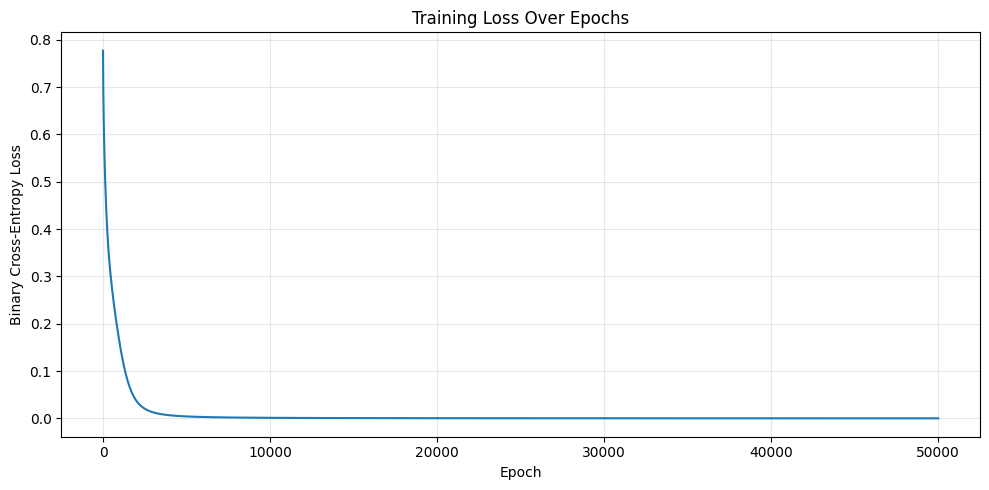

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(model.loss)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluation on Test Set

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# Predict on test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 40)
print("       MLP Evaluation Results")
print("=" * 40)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("=" * 40)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Attrition", "Attrition"]))

       MLP Evaluation Results
Accuracy:  0.9290
Precision: 0.9073
Recall:    0.9553
F1 Score:  0.9307

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.95      0.90      0.93       247
   Attrition       0.91      0.96      0.93       246

    accuracy                           0.93       493
   macro avg       0.93      0.93      0.93       493
weighted avg       0.93      0.93      0.93       493



## Confusion Matrix

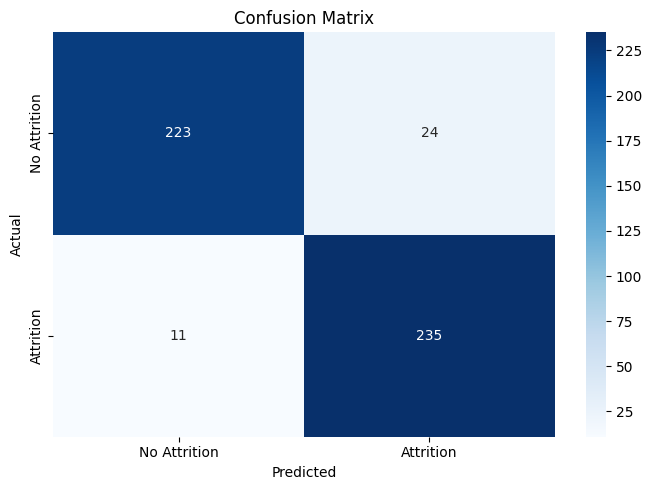

In [23]:
# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Attrition", "Attrition"],
            yticklabels=["No Attrition", "Attrition"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

---
# PyTorch MLP — Comparison
Same architecture: **36 → 64 (ReLU) → 32 (ReLU) → 1 (Sigmoid)** — but using PyTorch with Adam optimizer.

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim

# Convert data to PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

# PyTorch MLP: Same architecture as from-scratch MLP
class PyTorchMLP(nn.Module):
    def __init__(self, input_dim):
        super(PyTorchMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),  # Input -> Hidden 1
            nn.ReLU(),
            nn.Linear(64, 32),          # Hidden 1 -> Hidden 2
            nn.ReLU(),
            nn.Linear(32, 1),           # Hidden 2 -> Output
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

pytorch_mlp = PyTorchMLP(input_dim=X_train.shape[1])
print(pytorch_mlp)
print(f"\nTotal parameters: {sum(p.numel() for p in pytorch_mlp.parameters()):,}")

PyTorchMLP(
  (network): Sequential(
    (0): Linear(in_features=36, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

Total parameters: 4,481


## Train PyTorch MLP

In [30]:
torch.manual_seed(42)

criterion = nn.BCELoss()
optimizer = optim.Adam(pytorch_mlp.parameters(), lr=0.05) 

pytorch_losses = []
epochs = 50000

for epoch in range(epochs):
    y_pred = pytorch_mlp(X_train_t)
    loss = criterion(y_pred, y_train_t)
    pytorch_losses.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        with torch.no_grad():
            pred = (y_pred >= 0.5).float()
            acc = (pred == y_train_t).float().mean()
        print(f"Epoch {epoch:>5d} | Loss: {loss.item():.6f} | Train Acc: {acc.item():.4f}")

Epoch     0 | Loss: 0.000085 | Train Acc: 1.0000
Epoch  1000 | Loss: 0.000010 | Train Acc: 1.0000
Epoch  2000 | Loss: 0.000001 | Train Acc: 1.0000
Epoch  3000 | Loss: 0.000000 | Train Acc: 1.0000
Epoch  4000 | Loss: 0.000000 | Train Acc: 1.0000
Epoch  5000 | Loss: 0.000000 | Train Acc: 1.0000
Epoch  6000 | Loss: 0.000000 | Train Acc: 1.0000
Epoch  7000 | Loss: 0.000000 | Train Acc: 1.0000
Epoch  8000 | Loss: 0.000000 | Train Acc: 1.0000
Epoch  9000 | Loss: 0.000000 | Train Acc: 1.0000
Epoch 10000 | Loss: 0.000000 | Train Acc: 1.0000
Epoch 11000 | Loss: 0.000000 | Train Acc: 1.0000
Epoch 12000 | Loss: 0.000000 | Train Acc: 1.0000
Epoch 13000 | Loss: 0.000000 | Train Acc: 1.0000
Epoch 14000 | Loss: 0.000000 | Train Acc: 1.0000
Epoch 15000 | Loss: 0.000000 | Train Acc: 1.0000
Epoch 16000 | Loss: 0.000000 | Train Acc: 1.0000
Epoch 17000 | Loss: 0.000000 | Train Acc: 1.0000
Epoch 18000 | Loss: 0.000000 | Train Acc: 1.0000
Epoch 19000 | Loss: 0.000000 | Train Acc: 1.0000
Epoch 20000 | Loss: 

## PyTorch MLP — Loss Curve

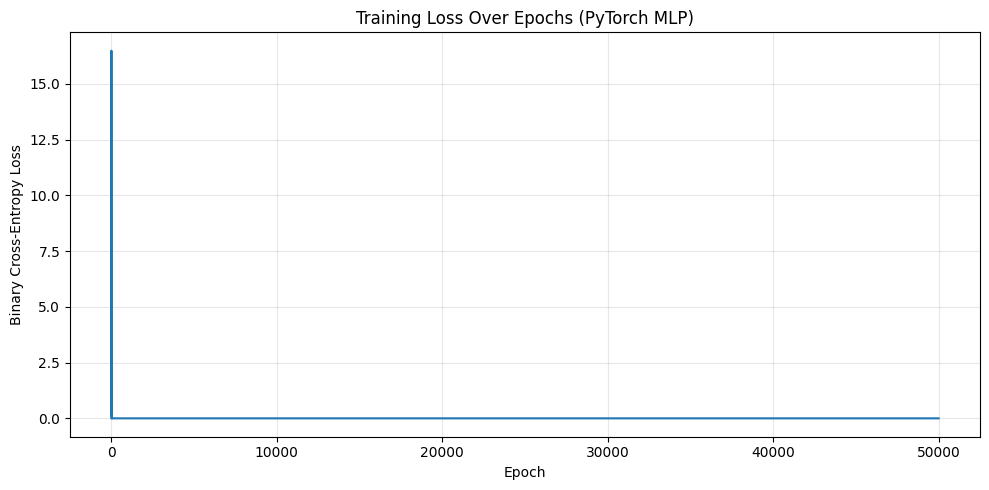

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(pytorch_losses)
plt.title("Training Loss Over Epochs (PyTorch MLP)")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## PyTorch MLP — Evaluation

In [33]:
pytorch_mlp.eval()
with torch.no_grad():
    y_pred_prob_pt = pytorch_mlp(X_test_t).numpy()
    y_pred_pt = (y_pred_prob_pt >= 0.5).astype(int)

accuracy_pt = accuracy_score(y_test, y_pred_pt)
precision_pt = precision_score(y_test, y_pred_pt)
recall_pt = recall_score(y_test, y_pred_pt)
f1_pt = f1_score(y_test, y_pred_pt)

print("=" * 40)
print("   PyTorch MLP Evaluation Results")
print("=" * 40)
print(f"Accuracy:  {accuracy_pt:.4f}")
print(f"Precision: {precision_pt:.4f}")
print(f"Recall:    {recall_pt:.4f}")
print(f"F1 Score:  {f1_pt:.4f}")
print("=" * 40)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pt, target_names=["No Attrition", "Attrition"]))

   PyTorch MLP Evaluation Results
Accuracy:  0.9270
Precision: 0.8918
Recall:    0.9715
F1 Score:  0.9300

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.97      0.88      0.92       247
   Attrition       0.89      0.97      0.93       246

    accuracy                           0.93       493
   macro avg       0.93      0.93      0.93       493
weighted avg       0.93      0.93      0.93       493



## PyTorch MLP — Confusion Matrix

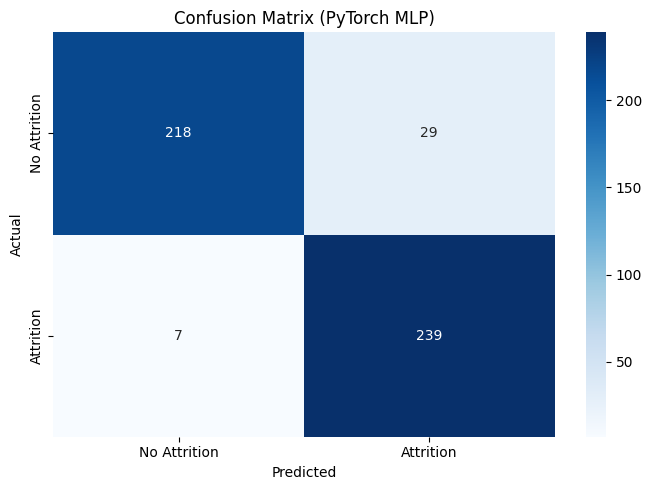

In [34]:
cm_pt = confusion_matrix(y_test, y_pred_pt)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_pt, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Attrition", "Attrition"],
            yticklabels=["No Attrition", "Attrition"])
plt.title("Confusion Matrix (PyTorch MLP)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## MLP Comparison: From Scratch vs PyTorch

     MLP Comparison: From Scratch vs PyTorch
   Metric  MLP (Scratch)  MLP (PyTorch)
 Accuracy       0.929006       0.926978
Precision       0.907336       0.891791
   Recall       0.955285       0.971545
 F1 Score       0.930693       0.929961


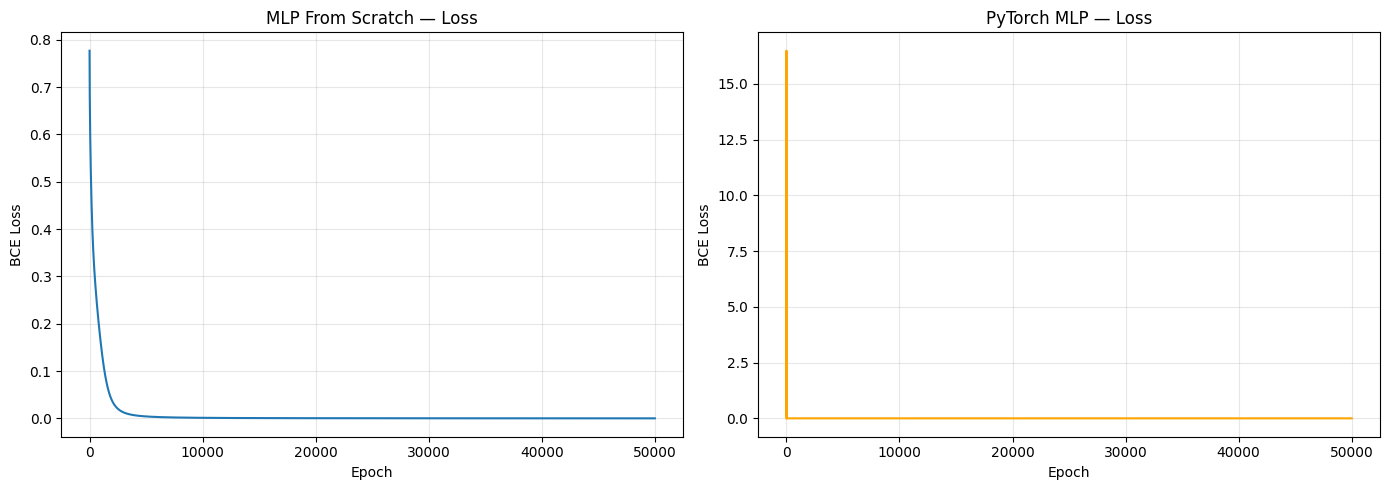

In [35]:
import pandas as pd

comparison_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "MLP (Scratch)": [accuracy, precision, recall, f1],
    "MLP (PyTorch)": [accuracy_pt, precision_pt, recall_pt, f1_pt]
}

comparison_df = pd.DataFrame(comparison_data)
print("=" * 55)
print("     MLP Comparison: From Scratch vs PyTorch")
print("=" * 55)
print(comparison_df.to_string(index=False))
print("=" * 55)

# Side-by-side loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(model.loss)
axes[0].set_title("MLP From Scratch — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(pytorch_losses, color="orange")
axes[1].set_title("PyTorch MLP — Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("BCE Loss")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()